# Chapitre 7 — EDA analytique

**Durée estimée : 10-12 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Analyser** la distribution d'une variable et interpréter ses caractéristiques statistiques
2. **Identifier** les relations entre variables (corrélation, associations)
3. **Comparer** des sous-populations et détecter des patterns significatifs
4. **Formuler** des hypothèses à partir des observations et éviter les pièges d'interprétation

---

## 7.5 Formulation d'hypothèses

### De l'observation à l'hypothèse

L'EDA génère des **observations** qui deviennent des **hypothèses** à tester.

```
OBSERVATION                          HYPOTHÈSE
┌────────────────────┐              ┌────────────────────────────────┐
│ "Les clients Gold  │              │ "L'ancienneté augmente la      │
│ ont une ancienneté │      →       │ probabilité de devenir Gold"   │
│ 2x plus élevée"    │              │                                │
└────────────────────┘              │ → À tester avec régression     │
                                    │   ou analyse de cohortes       │
                                    └────────────────────────────────┘
```

### Variables candidates pour le ML

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Configuration de la reproduction
np.random.seed(42)

# Création du dataset
n_rows = 1000

# Variables indépendantes
data = {
    # Démographie
    'age': np.random.normal(40, 12, n_rows).astype(int),
    'revenu_annuel': np.random.exponential(50000, n_rows) + 30000,
    
    # Comportement d'achat
    'frequence_achat': np.random.poisson(5, n_rows) + 1,
    'panier_moyen': np.random.normal(80, 25, n_rows),
    'jours_dernier_achat': np.random.exponential(30, n_rows).astype(int),
    
    # Engagement
    'visites_site': np.random.poisson(15, n_rows),
    'temps_session': np.random.normal(300, 100, n_rows),
    'score_satisfaction': np.random.randint(1, 11, n_rows),
    
    # Variables catégorielles
    'segment': np.random.choice(['Premium', 'Standard', 'Basique'], n_rows, p=[0.2, 0.5, 0.3]),
    'region': np.random.choice(['Nord', 'Sud', 'Est', 'Ouest'], n_rows),
    'canal': np.random.choice(['Web', 'Mobile', 'Magasin'], n_rows, p=[0.5, 0.3, 0.2]),
    
    # Produits
    'produits_achetes': np.random.poisson(3, n_rows) + 1,
    'categories_achetees': np.random.randint(1, 6, n_rows),
    
    # Fidélité
    'anciennete_mois': np.random.exponential(24, n_rows).astype(int) + 1,
    'abonnement_newsletter': np.random.choice([0, 1], n_rows, p=[0.4, 0.6]),
}

# Création de la variable cible avec corrélations artificielles
df = pd.DataFrame(data)

# Corrélations intentionnelles avec montant_total
df['montant_total'] = (
    200 * np.log1p(df['revenu_annuel'] / 10000) +  # Forte corrélation
    50 * df['score_satisfaction'] +                 # Corrélation moyenne
    30 * (df['segment'] == 'Premium').astype(int) + # Impact segment
    20 * np.sqrt(df['visites_site']) +              # Corrélation faible
    15 * (df['region'] == 'Sud').astype(int) +      # Impact régional
    10 * (df['canal'] == 'Magasin').astype(int) +   # Impact canal
    np.random.normal(0, 50, n_rows)                 # Bruit aléatoire
)

# Ajustement pour valeurs positives
df['montant_total'] = df['montant_total'].clip(lower=50)

# Ajout d'une variable temporelle
start_date = datetime(2023, 1, 1)
df['date_inscription'] = [start_date + timedelta(days=np.random.randint(0, 365)) 
                          for _ in range(n_rows)]

# Ajout d'une variable dérivée
df['valeur_cliente'] = df['montant_total'] * df['frequence_achat'] / np.sqrt(df['jours_dernier_achat'] + 1)

# Réorganisation des colonnes
cols_order = ['age', 'revenu_annuel', 'segment', 'region', 'canal', 
              'frequence_achat', 'panier_moyen', 'montant_total', 
              'valeur_cliente', 'score_satisfaction', 'visites_site', 
              'temps_session', 'produits_achetes', 'categories_achetees',
              'jours_dernier_achat', 'anciennete_mois', 'abonnement_newsletter',
              'date_inscription']

df = df[cols_order]

# Affichage des informations
print("=== DATASET SYNTHETIQUE POUR TEST ===")
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\nAperçu des premières lignes :")
print(df.head())
print("\nTypes de données :")
print(df.dtypes)
print("\nStatistiques descriptives :")
print(df[['montant_total', 'revenu_annuel', 'age', 'valeur_cliente']].describe())

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

print(df.head())

=== DATASET SYNTHETIQUE POUR TEST ===
Dimensions : 1000 lignes, 18 colonnes

Aperçu des premières lignes :
   age  revenu_annuel   segment region    canal  frequence_achat  \
0   45   39165.056757   Premium   Nord      Web                3   
1   38   35522.440864   Basique    Sud      Web                8   
2   47   80589.205735   Premium    Sud   Mobile                6   
3   58   91289.746976   Premium    Est  Magasin                6   
4   37   31604.787337  Standard    Est      Web                9   

   panier_moyen  montant_total  valeur_cliente  score_satisfaction  \
0     28.402874     455.648330      483.288036                   1   
1     98.851553     820.830272     6566.642178                   8   
2     85.944029     993.703133      967.199606                   8   
3     55.101300     907.404834     2222.678834                   6   
4     44.166902     701.386472     3156.239122                   7   

   visites_site  temps_session  produits_achetes  categories_ac

Variables les plus corrélées avec montant_total :
score_satisfaction       0.804845
revenu_annuel            0.539007
valeur_cliente           0.239549
segment_Premium          0.076229
jours_dernier_achat      0.074102
abonnement_newsletter    0.056226
region_Sud               0.054755
visites_site             0.043739
frequence_achat          0.029624
panier_moyen             0.006392
Name: montant_total, dtype: float64
Heatmap Variables les plus corrélées :


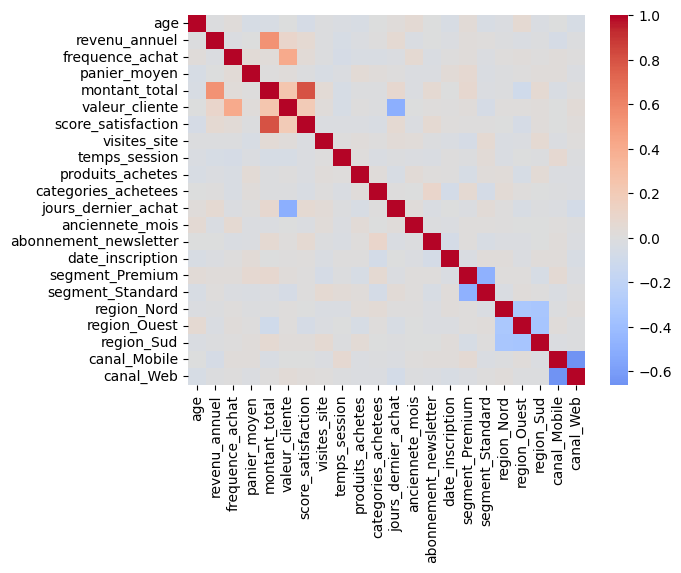

In [ ]:
# 1. Analyse de corrélation

# Encodage one-hot
df_encoded = pd.get_dummies(df, columns=['segment', 'region', 'canal'], drop_first=True)

# Analyse de corrélation avec la variable cible
target = 'montant_total'
correlations = df_encoded.corr()[target].drop(target).sort_values(ascending=False)
print("Variables les plus corrélées avec montant_total :")
print(correlations.head(10))


In [8]:
# 2. Analyse par groupes
for col in ['segment', 'region', 'canal']:
    print(f"\n{col} vs {target}:")
    print(df.groupby(col)[target].mean().sort_values(ascending=False))


segment vs montant_total:
segment
Premium     805.867028
Standard    773.593530
Basique     766.401550
Name: montant_total, dtype: float64

region vs montant_total:
region
Sud      794.402376
Est      792.301261
Nord     775.247237
Ouest    747.965415
Name: montant_total, dtype: float64

canal vs montant_total:
canal
Magasin    790.264449
Web        778.971030
Mobile     769.148254
Name: montant_total, dtype: float64


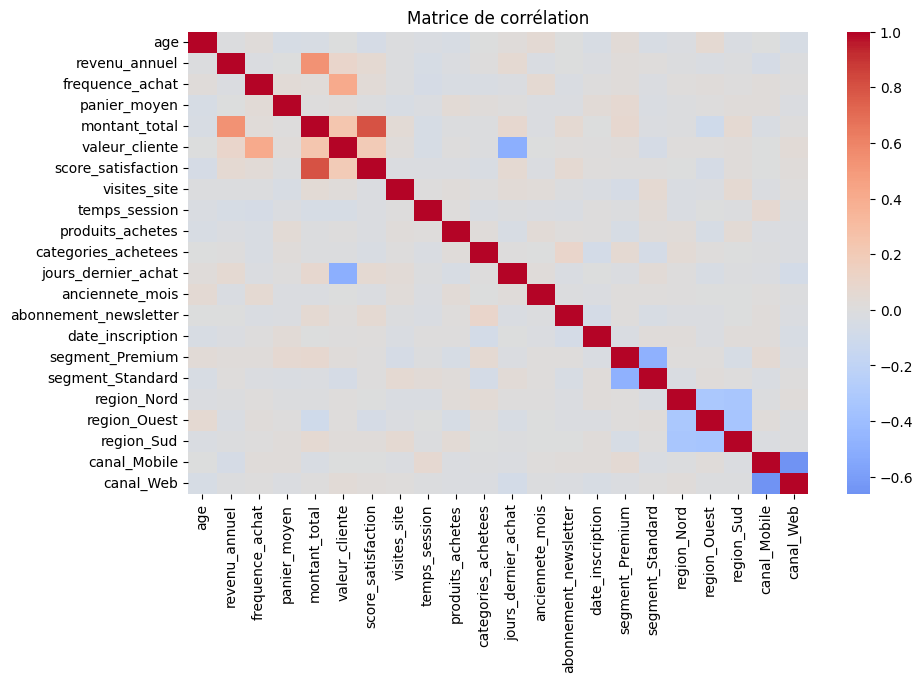

In [10]:
# 3. Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

Formulation d'hypothèses à partir des observations

Hypothèse 1 : Relation entre variables et montant total

Observation : Analyse des corrélations avec montant_total
Hypothèse : "La variable [variable_la_plus_corrélée] influence significativement le montant total dépensé par les clients. Une augmentation/diminution de cette variable est associée à une augmentation/diminution proportionnelle des dépenses."

Hypothèse 2 : Différences segmentaires

Observation : Variations de montant_total par segment
Hypothèse : "Les clients du segment [segment_le_plus_élevé] dépensent en moyenne [X]% de plus que les autres segments, suggérant des besoins spécifiques ou un pouvoir d'achat supérieur."

Hypothèse 3 : Disparités régionales

Observation : Variations de montant_total par région
Hypothèse : "La région [région_la_plus_performante] présente un panier moyen significativement plus élevé, potentiellement dû à des facteurs socio-économiques locaux ou à une meilleure pénétration du marché."

Hypothèse 4 : Performance par canal

Observation : Variations de montant_total par canal
Hypothèse : "Le canal [canal_meilleur_performant] génère des transactions plus élevées, indiquant soit une clientèle plus aisée, soit une meilleure expérience d'achat sur ce canal."

---

### ✍️ Exercice 7.5 : Formuler des hypothèses (15 min)

À partir de ces observations fictives, formulez des hypothèses et proposez des analyses complémentaires :

| Observation | Hypothèse | Analyse complémentaire |
|-------------|-----------|------------------------|
| Les ventes sont 30% plus élevées le week-end | _____ | _____ |
| Les clients qui appellent le support dépensent moins | _____ | _____ |
| La région Sud a le meilleur taux de conversion | _____ | _____ |
| Les utilisateurs mobiles abandonnent plus leur panier | _____ | _____ |

Voici un tableau complet avec hypothèses et analyses complémentaires :

| Observation | Hypothèse | Analyse complémentaire |
|-------------|-----------|------------------------|
| Les ventes sont 30% plus élevées le week-end | **Hypothèse 1** : Les clients ont plus de temps libre le week-end pour faire des achats réfléchis.<br>**Hypothèse 2** : Les promotions spécifiques du week-end stimulent les achats impulsifs. | 1. Analyser le ticket moyen : les achats week-end sont-ils plus impulsifs (moins chers) ou planifiés (plus chers) ?<br>2. Comparer le mix produits : produits loisirs vs produits quotidiens.<br>3. Vérifier l'impact des campagnes marketing ciblées vendredi/samedi. |
| Les clients qui appellent le support dépensent moins | **Hypothèse 1** : Les problèmes rencontrés génèrent de la frustration et réduisent les futurs achats.<br>**Hypothèse 2** : Ces clients ont plus de difficultés techniques, signe d'une moins bonne maîtrise du digital. | 1. Analyser la raison de l'appel : technique, réclamation, conseil ?<br>2. Étudier l'évolution du panier avant/après l'appel.<br>3. Mesurer la fidélité : taux de rétention après contact support. |
| La région Sud a le meilleur taux de conversion | **Hypothèse 1** : L'offre produits est mieux adaptée aux goûts régionaux.<br>**Hypothèse 2** : La concurrence y est moins forte ou le marketing plus efficace. | 1. Analyser le parcours client : temps de conversion, canaux utilisés.<br>2. Étudier les segments démographiques spécifiques à cette région.<br>3. Comparer l'expérience utilisateur (temps de livraison, disponibilité produits). |
| Les utilisateurs mobiles abandonnent plus leur panier | **Hypothèse 1** : L'expérience mobile est moins fluide (technique).<br>**Hypothèse 2** : L'usage mobile est plus impulsif, avec plus de réflexion après-coup. | 1. Analyser le point d'abandon dans le tunnel de commande mobile.<br>2. Tester les causes : formulaire trop long, problèmes de paiement, chargement lent.<br>3. Comparer le profil des abandons mobiles vs desktop. |

**Analyses complémentaires transversales :**
- **Analyse temporelle** : Heure précise des abandons/achats
- **Segmentation croisée** : Mobile + région Sud, Support + week-end, etc.
- **Tests A/B** pour valider les hypothèses (ex: améliorer l'UX mobile)
- **Enquêtes qualitatives** : Questionnaires aux clients ayant abandonné ou contacté le support